# Sales Analysis Project

# Project Objective
The objective of this project is to analyze retail sales data to identify sales trends, profit patterns, customer segments, regional performance, and business insights using Python, Pandas, Matplotlib, and Seaborn.

In [1]:
# Import Libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Data Understanding

In [2]:
#load dataset and see first 5 columns

df = pd.read_excel("Sample - Superstore.xlsx")
df.head()

C:\Users\User\AppData\Local\Programs\Python\Python312\Lib\site-packages\openpyxl\worksheet\header_footer.py:48: UserWarning: Cannot parse header or footer so it will be ignored
  warn("""Cannot parse header or footer so it will be ignored""")


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2017-138688,2017-06-12,2017-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [3]:
#see last 5 rows
df.tail()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
9989,9990,CA-2015-110422,2015-01-21,2015-01-23,Second Class,TB-21400,Tom Boeckenhauer,Consumer,United States,Miami,...,33180.0,South,FUR-FU-10001889,Furniture,Furnishings,Ultra Door Pull Handle,25.248,3,0.2,4.1028
9990,9991,CA-2018-121258,2018-02-26,2018-03-03,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,...,92627.0,West,FUR-FU-10000747,Furniture,Furnishings,Tenex B1-RE Series Chair Mats for Low Pile Car...,91.960,2,0.0,15.6332
9991,9992,CA-2018-121258,2018-02-26,2018-03-03,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,...,92627.0,West,TEC-PH-10003645,Technology,Phones,Aastra 57i VoIP phone,258.576,2,0.2,19.3932
9992,9993,CA-2018-121258,2018-02-26,2018-03-03,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,...,92627.0,West,OFF-PA-10004041,Office Supplies,Paper,"It's Hot Message Books with Stickers, 2 3/4"" x 5""",29.600,4,0.0,13.3200
9993,9994,CA-2018-119914,2018-05-04,2018-05-09,Second Class,CC-12220,Chris Cortes,Consumer,United States,Westminster,...,92683.0,West,OFF-AP-10002684,Office Supplies,Appliances,"Acco 7-Outlet Masterpiece Power Center, Wihtou...",243.160,2,0.0,72.9480


In [5]:
#view summary statistics
df.describe()

,Row ID,Order Date,Ship Date,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994,9994,9983.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,2017-04-30 05:17:08.056834,2017-05-04 04:17:20.304182,55245.233297,229.858001,3.789574,0.156203,28.656896
min,1.000000,2015-01-03 00:00:00,2015-01-07 00:00:00,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,2016-05-23 00:00:00,2016-05-27 00:00:00,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,2017-06-26 00:00:00,2017-06-29 00:00:00,57103.000000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,2018-05-14 00:00:00,2018-05-18 00:00:00,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,2018-12-30 00:00:00,2019-01-05 00:00:00,99301.000000,22638.480000,14.000000,0.800000,8399.976000
std,2885.163629,NaN,NaN,32038.715955,623.245101,2.225110,0.206452,234.260108


Obsservation-
The average sales value is approximately 229, while the maximum sale is 22,638. Profit ranges from -6,599 to 8,399, indicating that some orders generated losses.

### Data Shapes & Missing Values

In [6]:
#rows and columns
df.shape

(9994, 21)

Observation-
The dataset contains 9,994 rows and 21 columns, indicating that it is a moderately sized retail sales dataset.

In [7]:
df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit'],
      dtype='str')

In [8]:
df.dtypes

Row ID                    int64
Order ID                    str
Order Date       datetime64[us]
Ship Date        datetime64[us]
Ship Mode                   str
Customer ID                 str
Customer Name               str
Segment                     str
Country                     str
City                        str
State                       str
Postal Code             float64
Region                      str
Product ID                  str
Category                    str
Sub-Category                str
Product Name                str
Sales                   float64
Quantity                  int64
Discount                float64
Profit                  float64
dtype: object

Observation-
The dataset contains numerical, categorical, and datetime columns. The Order Date and Ship Date columns are stored in datetime format, making them suitable for time-based analysis.
All columns have appropriate data types, so no datatype conversion was required.

In [9]:
#Dataset Information
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row ID         9994 non-null   int64         
 1   Order ID       9994 non-null   str           
 2   Order Date     9994 non-null   datetime64[us]
 3   Ship Date      9994 non-null   datetime64[us]
 4   Ship Mode      9994 non-null   str           
 5   Customer ID    9994 non-null   str           
 6   Customer Name  9994 non-null   str           
 7   Segment        9994 non-null   str           
 8   Country        9994 non-null   str           
 9   City           9994 non-null   str           
 10  State          9994 non-null   str           
 11  Postal Code    9983 non-null   float64       
 12  Region         9994 non-null   str           
 13  Product ID     9994 non-null   str           
 14  Category       9994 non-null   str           
 15  Sub-Category   9994 non-null   s

Observation-
There are some non null values in Postal code column 

In [10]:
df.isnull().sum()

Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
Country           0
City              0
State             0
Postal Code      11
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
Quantity          0
Discount          0
Profit            0
dtype: int64

Only the Postal Code column contains 11 missing values, while all other columns have complete data.

In [11]:
df.duplicated().sum()

np.int64(0)

Observation-
No duplicate records were found in the dataset.

# Basic EDA

In [12]:
df['Category'].unique()

<StringArray>
['Furniture', 'Office Supplies', 'Technology']
Length: 3, dtype: str

Observation-
The dataset contains 3 product categories: Furniture, Office Supplies, and Technology.

In [17]:
df['Segment'].unique()

<StringArray>
['Consumer', 'Corporate', 'Home Office']
Length: 3, dtype: str

Observation-
The customers are divided into 3 segments: Consumer, Corporate, and Home Office

In [19]:
df['Ship Mode'].unique()

<StringArray>
['Second Class', 'Standard Class', 'First Class', 'Same Day']
Length: 4, dtype: str

Observation-
The company offers 4 shipping modes: Standard Class, Second Class, First Class, and Same Day

In [21]:
df['Category'].value_counts()

Category
Office Supplies    6026
Furniture          2121
Technology         1847
Name: count, dtype: int64

Observation-
Office Supplies has the highest number of orders (6,026), followed by Furniture (2,121) and Technology (1,847).

In [22]:
df['Region'].value_counts()

Region
West       3203
East       2848
Central    2323
South      1620
Name: count, dtype: int64

Observation-
The dataset contains orders from 4 regions.
West has the highest number of orders 3203
South has the lowest number of orders 1620

In [23]:
df['Segment'].value_counts()

Segment
Consumer       5191
Corporate      3020
Home Office    1783
Name: count, dtype: int64

Observation-
The Consumer segment has the highest number of orders 5191
Corporate is the second largest segment
Home Office has the fewest orders

In [24]:
df['Ship Mode'].value_counts()

Ship Mode
Standard Class    5968
Second Class      1945
First Class       1538
Same Day           543
Name: count, dtype: int64

Observatiom-
Standard Class is the most frequently used shipping mode
Same Day is the least frequently used shipping option

## Data Cleaning

In [25]:
df.drop('Postal Code',axis=1,inplace = True)

The Postal Code column contained a small number of missing values and was not required for the planned business analysis

In [26]:
df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name',
       'Sales', 'Quantity', 'Discount', 'Profit'],
      dtype='str')

In [27]:
df.shape

(9994, 20)

In [28]:
df.duplicated().sum()

np.int64(0)

In [29]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 20 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row ID         9994 non-null   int64         
 1   Order ID       9994 non-null   str           
 2   Order Date     9994 non-null   datetime64[us]
 3   Ship Date      9994 non-null   datetime64[us]
 4   Ship Mode      9994 non-null   str           
 5   Customer ID    9994 non-null   str           
 6   Customer Name  9994 non-null   str           
 7   Segment        9994 non-null   str           
 8   Country        9994 non-null   str           
 9   City           9994 non-null   str           
 10  State          9994 non-null   str           
 11  Region         9994 non-null   str           
 12  Product ID     9994 non-null   str           
 13  Category       9994 non-null   str           
 14  Sub-Category   9994 non-null   str           
 15  Product Name   9994 non-null   s

## Feature Engineering

In [30]:
df['Shipping Days'] = (df['Ship Date']-df['Order Date']).dt.days

In [31]:
df[['Order Date', 'Ship Date', 'Shipping Days']].head()

,Order Date,Ship Date,Shipping Days
0,2017-11-08,2017-11-11,3
1,2017-11-08,2017-11-11,3
2,2017-06-12,2017-06-16,4
3,2016-10-11,2016-10-18,7
4,2016-10-11,2016-10-18,7


Observation-
A new column was created to calculate the number of days taken to ship each order.

In [32]:
df['Order Year'] = df['Order Date'].dt.year

In [33]:
df[['Order Date', 'Order Year']].head()

,Order Date,Order Year
0,2017-11-08,2017
1,2017-11-08,2017
2,2017-06-12,2017
3,2016-10-11,2016
4,2016-10-11,2016


In [34]:
df['Order Year'].unique()

array([2017, 2016, 2015, 2018], dtype=int32)

In [35]:
df['Order Year'].value_counts()

Order Year
2018    3312
2017    2587
2016    2102
2015    1993
Name: count, dtype: int64

Observation-
A new feature, Order Year, was created successfully. The dataset contains orders from 2015 to 2018.

In [36]:
df.groupby('Order Year')['Sales'].sum()

Order Year
2015    484247.4981
2016    470532.5090
2017    609205.5980
2018    733215.2552
Name: Sales, dtype: float64

Observation-
2018 recorded the highest sales of 733,215.26.
2016 recorded the lowest sales of 470,532.51.
Sales decreased slightly from 2015 to 2016.
Sales then increased significantly in 2017 and reached the highest level in 2018

In [37]:
df['Order Month'] = df['Order Date'].dt.month_name()

In [38]:
df[['Order Date','Order Month']].head()

,Order Date,Order Month
0,2017-11-08,November
1,2017-11-08,November
2,2017-06-12,June
3,2016-10-11,October
4,2016-10-11,October


Observation-
The Order Month feature was created successfully. Each order date has been correctly converted into its corresponding month name (e.g., November, June, October). This new feature will be used for month-wise sales analysis.

In [39]:
df.groupby('Order Month')['Sales'].sum()

Order Month
April        137762.1286
August       159044.0630
December     325293.5035
February      59751.2514
January       94924.8356
July         147238.0970
June         152718.6793
March        205005.4888
May          155028.8117
November     352461.0710
October      200322.9847
September    307649.9457
Name: Sales, dtype: float64

Observation-
November generated the highest sales of 352,461.07.
December recorded the second-highest sales of 325,293.50.
September also performed well with 307,649.95 in sales.
February generated the lowest sales of 59,751.25

# Business EDA

In [40]:
#category wise sales
category_sales = df.groupby('Category')['Sales'].sum()

Observation-
Technology generated the highest sales, followed by Furniture and Office Supplies.

Business Insight-
Technology is the leading revenue-generating category and contributes the largest share of total sales.

In [43]:
#category wise profit
category_profit = df.groupby('Category')['Profit'].sum()

Observation-
Technology generated the highest profit, while Furniture generated the lowest profit.

Business Insight-
Although Furniture has strong sales, its profit is relatively low, indicating lower profitability compared to other categories.

In [44]:
#Region wise sales
region_sales = df.groupby('Region')['Sales'].sum()

Observation-
West region generated the highest sales, while South region generated the lowest sales.

Business Insight-
The West region contributes the largest share of total revenue, whereas the South region has growth potential.

In [45]:
# Region wise profit
region_profit = df.groupby('Region')['Profit'].sum()

Observation-
West region generated the highest profit, while Central region generated the lowest profit.

Business Insight-
The West region is the company's strongest market in terms of profitability. The Central region requires further analysis to identify the reasons behind its lower profit.

In [46]:
# Segment wise sales
segment_sales = df.groupby('Segment')['Sales'].sum()

Observation-
West region generated the highest sales, while South region generated the lowest sales.

Business Insight-
The West region contributes the largest share of total revenue, whereas the South region has growth potential.

In [47]:
# Segment wise profit
segment_profit = df.groupby('Segment')['Profit'].sum()

Observation-
Consumer segment generated the highest profit.

Business Insight-
The Consumer segment contributes significantly to both revenue and profitability.

In [48]:
#Sub-Category Analysis

In [49]:
#sub category sales
df.groupby('Sub-Category')['Sales'].sum().sort_values(ascending=False)

Sub-Category
Phones         330007.0540
Chairs         328449.1030
Storage        223843.6080
Tables         206965.5320
Binders        203412.7330
Machines       189238.6310
Accessories    167380.3180
Copiers        149528.0300
Bookcases      114879.9963
Appliances     107532.1610
Furnishings     91705.1640
Paper           78479.2060
Supplies        46673.5380
Art             27118.7920
Envelopes       16476.4020
Labels          12486.3120
Fasteners        3024.2800
Name: Sales, dtype: float64

Observation-
Phones generated the highest sales.

Business Insight-
High-performing sub-categories such as Phones contribute significantly to overall sales.

In [50]:
#sub category sales
df.groupby('Sub-Category')['Profit'].sum().sort_values(ascending=False)

Sub-Category
Copiers        55617.8249
Phones         44515.7306
Accessories    41936.6357
Paper          34053.5693
Binders        30221.7633
Chairs         26590.1663
Storage        21278.8264
Appliances     18138.0054
Furnishings    13059.1436
Envelopes       6964.1767
Art             6527.7870
Labels          5546.2540
Machines        3384.7569
Fasteners        949.5182
Supplies       -1189.0995
Bookcases      -3472.5560
Tables        -17725.4811
Name: Profit, dtype: float64

Observation-
Copiers generated the highest profit, while Tables generated the largest loss.

Business Insight-
The company should investigate loss-making sub-categories and review pricing or discount strategies.

In [52]:
#Correlation Analysis

In [53]:
df[['Sales','Profit','Discount','Quantity']].corr()

,Sales,Profit,Discount,Quantity
Sales,1.000000,0.479064,-0.028190,0.200795
Profit,0.479064,1.000000,-0.219487,0.066253
Discount,-0.028190,-0.219487,1.000000,0.008623
Quantity,0.200795,0.066253,0.008623,1.000000


Correlation analysis shows a moderate positive relationship (0.479) between Sales and Profit, indicating that higher sales generally lead to higher profit. Discount and Profit have a negative correlation (-0.219), suggesting that increasing discounts tends to reduce profitability. The relationships between Quantity and Profit (0.066) and Discount and Sales (-0.028) are very weak, indicating little to no linear relationship.

## Data Visualization

Which category generates the highest sales?

In [54]:
#Sales by category

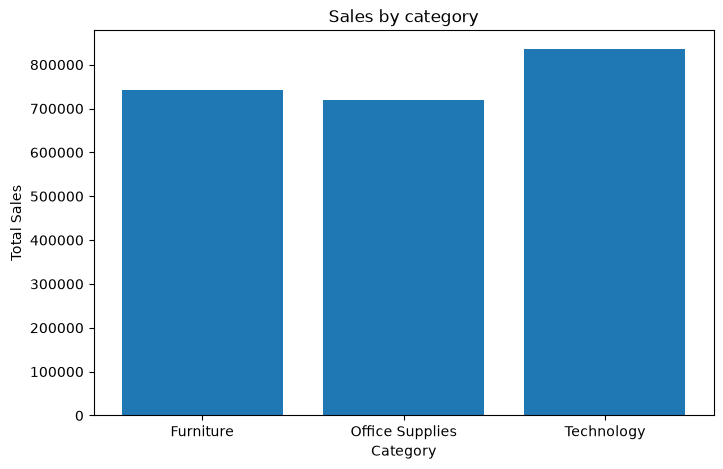

In [55]:
plt.figure(figsize=(8,5))
plt.bar(category_sales.index, category_sales.values)
plt.title("Sales by category")
plt.xlabel("Category")
plt.ylabel("Total Sales")
plt.show()

Observation-
Technology generated the highest sales, followed by Furniture and Office Supplies
Business Insight-
Technology is the company's highest revenue-generating category. Maintaining strong product availability and marketing efforts in this category can help sustain revenue growth, while the company can explore strategies to improve sales in the other categories.

Which category generates the highest profit?

In [56]:
#profit by category

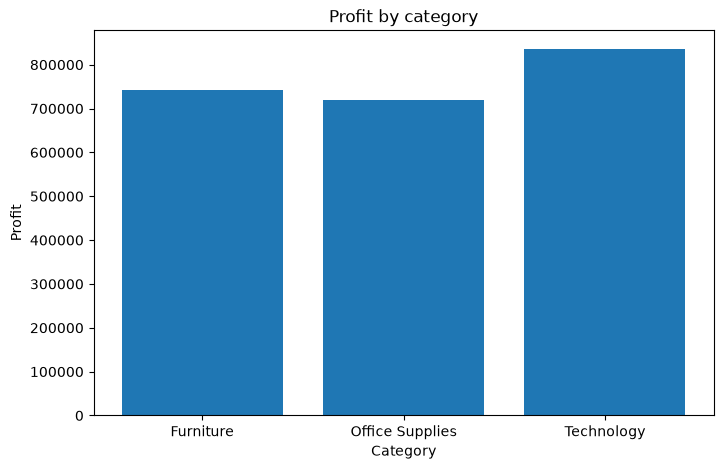

In [57]:
plt.figure(figsize=(8,5))
plt.bar(category_profit.index, category_sales.values)
plt.title("Profit by category")
plt.xlabel("Category")
plt.ylabel("Profit")
plt.show()

Observation-
Technology generated the highest profit, followed by Office Supplies. Furniture generated the lowest profit despite having relatively high sales.
Business Insight-
Although Furniture contributes significantly to sales, it generates comparatively low profit. This suggests lower profit margins or higher costs, making it a category that requires further business investigation.

In [58]:
#Sales by region

Which region generated the highest sales?

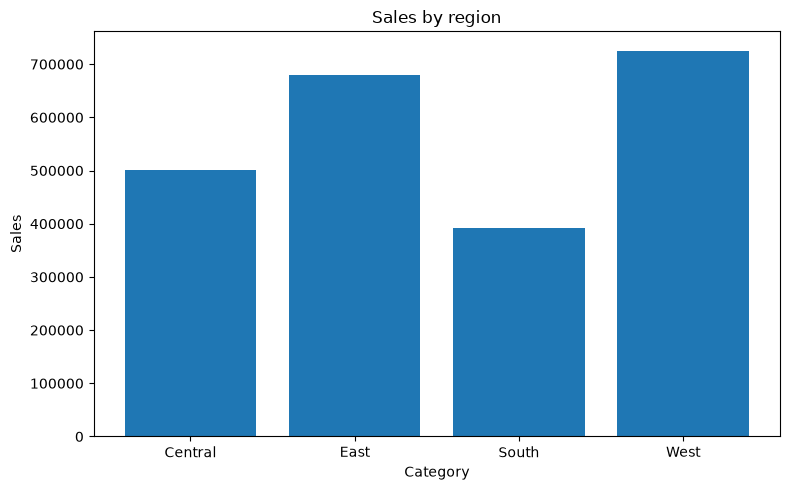

In [59]:
plt.figure(figsize=(8,5))
plt.bar(region_sales.index, region_sales.values)
plt.title("Sales by region")
plt.xlabel("Category")
plt.ylabel("Sales")
plt.tight_layout()
plt.show()

Observation-
The West region generated the highest sales, followed by the East region. The South region recorded the lowest sales.
Business Insight-
The West region is the company's strongest revenue-generating market. The South region contributes the least sales, indicating an opportunity for targeted marketing and business expansion.

In [60]:
#profit by region

Which region generated the highest profit?

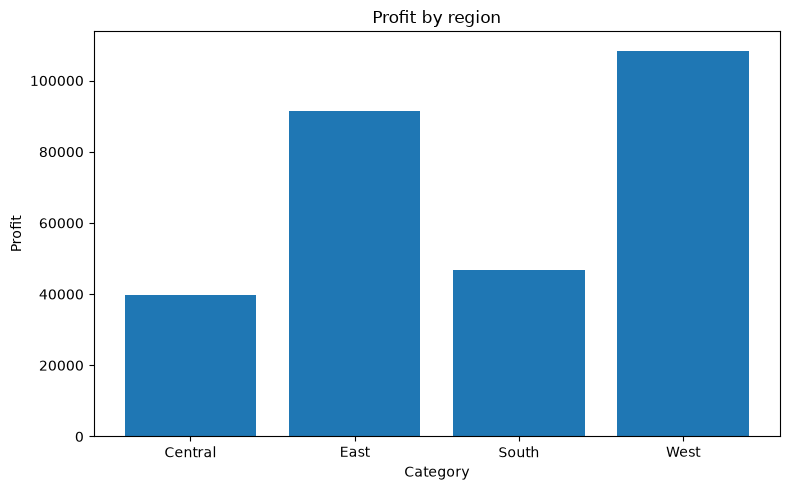

In [61]:
plt.figure(figsize=(8,5))
plt.bar(region_profit.index, region_profit.values)
plt.title("Profit by region")
plt.xlabel("Category")
plt.ylabel("Profit")
plt.tight_layout()
plt.show()

From your EDA-
The West region generated the highest profit, while the Central region generated the lowest profit.

Business Insight-
The West region is the most profitable market for the company. In contrast, the Central region has the lowest profit, indicating an opportunity to investigate pricing, discounts, product mix, or operational costs in that region.

In [63]:
# Sales by Segment

which segment generated highest segment

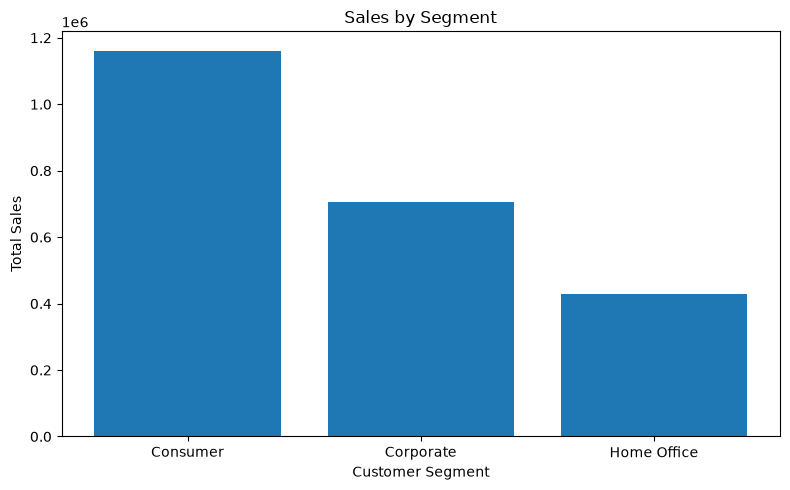

In [64]:
plt.figure(figsize=(8,5))

plt.bar(segment_sales.index, segment_sales.values)

plt.title("Sales by Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Total Sales")

plt.tight_layout()

plt.show()

Observation-
Based on your EDA:
The Consumer segment generated the highest sales, followed by Corporate. The Home Office segment generated the lowest sales.

Business Insight
The Consumer segment is the company's largest source of revenue. This suggests that individual customers contribute more to total sales than business or home office customers. The company can continue strengthening this segment while exploring strategies to increase sales in the Corporate and Home Office segments.

In [65]:
# Profit by Segment

Which segment generated highest Proft?

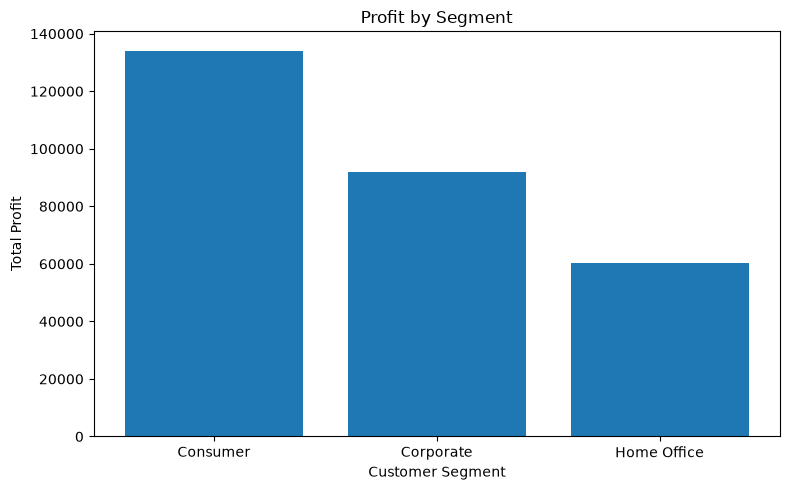

In [66]:
plt.figure(figsize=(8,5))

plt.bar(segment_profit.index, segment_profit.values)

plt.title("Profit by Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Total Profit")

plt.tight_layout()

plt.show()

Observation-
From your EDA:
The Consumer segment generated the highest profit, followed by Corporate. The Home Office segment generated the lowest profit.

Business Insight-
The Consumer segment contributes the highest profit to the business, making it the most valuable customer segment. The company should continue focusing on retaining Consumer customers while identifying opportunities to improve profitability in the Home Office segment.

# Year-wise Sales Trend

How have sales changed over the years?

In [67]:
year_sales = df.groupby('Order Year')['Sales'].sum()

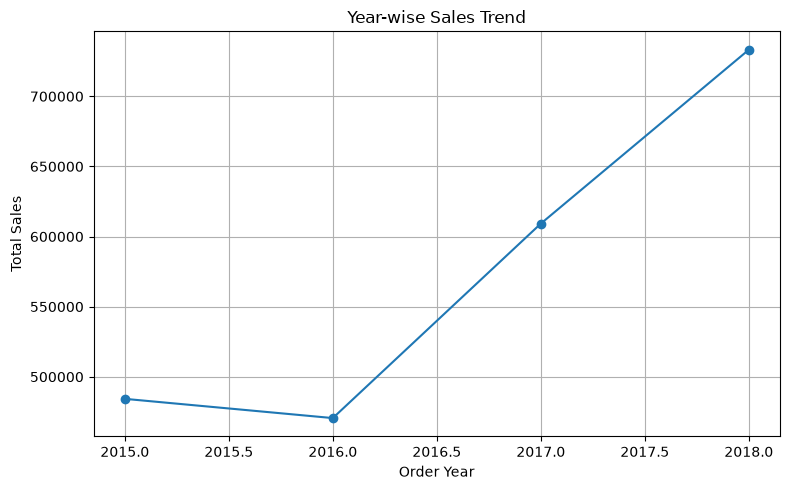

In [68]:
plt.figure(figsize=(8,5))

plt.plot(year_sales.index,
         year_sales.values,
         marker='o')

plt.title("Year-wise Sales Trend")
plt.xlabel("Order Year")
plt.ylabel("Total Sales")

plt.grid(True)

plt.tight_layout()

plt.show()

Observation-
Sales showed an overall upward trend from 2015 to 2018. There was a slight decline in 2016, followed by strong growth in 2017, with 2018 recording the highest sales.

Business Insight-
The company demonstrated consistent business growth over the four-year period. Although sales dipped slightly in 2016, the recovery in 2017 and record sales in 2018 suggest improving market performance and increasing customer demand.

In [69]:
month_sales = df.groupby('Order Month')['Sales'].sum()

In [70]:
month_order = [
    'January', 'February', 'March', 'April',
    'May', 'June', 'July', 'August',
    'September', 'October', 'November', 'December'
]

month_sales = month_sales.reindex(month_order)

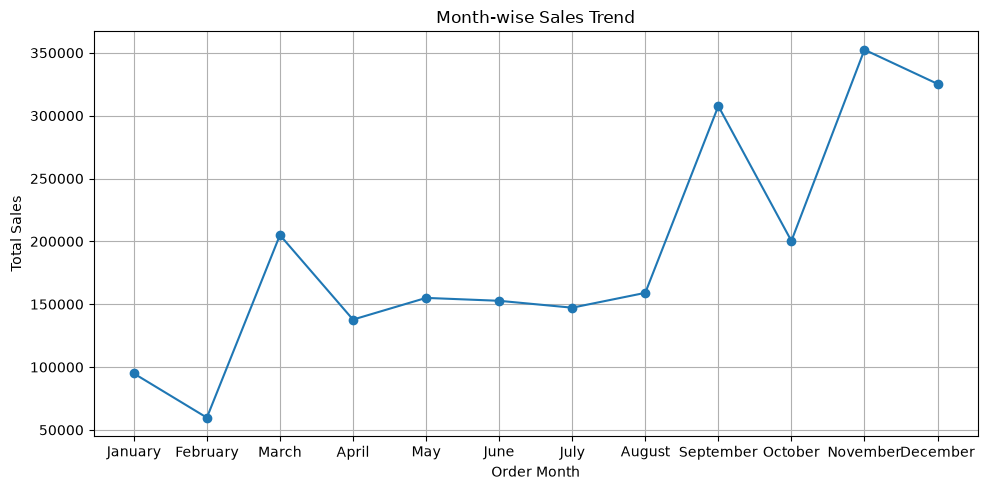

In [71]:
plt.figure(figsize=(10,5))

plt.plot(month_sales.index,
         month_sales.values,
         marker='o')

plt.title("Month-wise Sales Trend")
plt.xlabel("Order Month")
plt.ylabel("Total Sales")

plt.grid(True)

plt.tight_layout()

plt.show()

Observation-
Sales are lowest in February and increase gradually throughout the year. Sales peak in November, with December recording the second-highest sales. This indicates stronger business performance during the last quarter of the year.

Business Insight-
The company experiences higher sales during the year-end months, particularly November and December. This may be influenced by seasonal demand, festive shopping, or promotional campaigns. The company can plan inventory, staffing, and marketing activities accordingly to maximize sales during these peak months.

In [ ]:
# Top 10 Sub-Categories by Sale

In [ ]:
Which sub-categories generate the highest sales?

In [76]:
subcategory_sales = df.groupby('Sub-Category')['Sales'].sum().sort_values(ascending=False)

In [77]:
top10_sales = subcategory_sales.head(10)

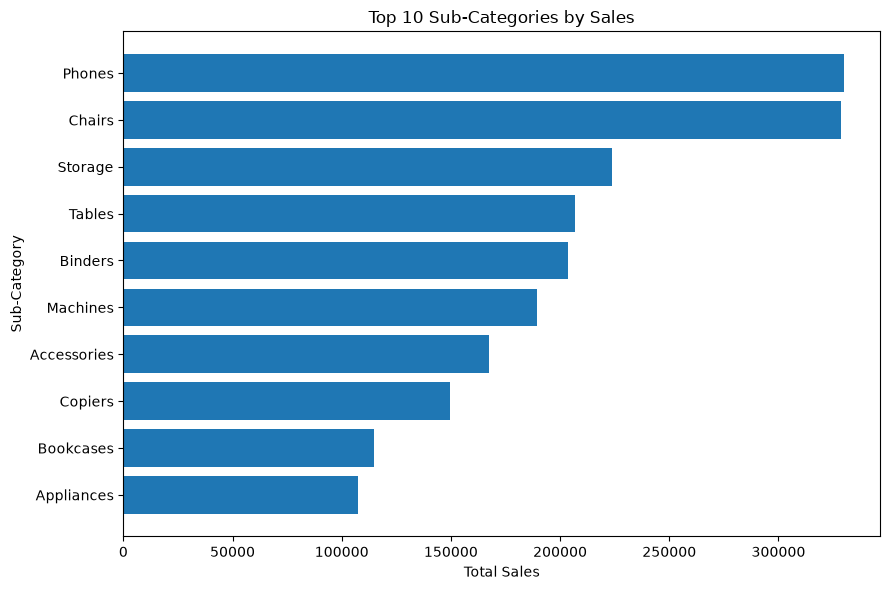

In [78]:
plt.figure(figsize=(9,6))

plt.barh(top10_sales.index,
         top10_sales.values)

plt.title("Top 10 Sub-Categories by Sales")
plt.xlabel("Total Sales")
plt.ylabel("Sub-Category")

plt.gca().invert_yaxis()

plt.tight_layout()

plt.show()

Observation-
Phones generated the highest sales, followed by Chairs and Storage. These sub-categories contribute significantly to overall revenue.

Business Insight-
The company should continue maintaining inventory and marketing efforts for the top-selling sub-categories, while analyzing the lower-performing sub-categories to identify opportunities for improvement.

Which sub-categories generate the highest profit?

In [79]:
subcategory_profit = df.groupby('Sub-Category')['Profit'].sum().sort_values(ascending=False)

In [80]:
top10_profit = subcategory_profit.head(10)

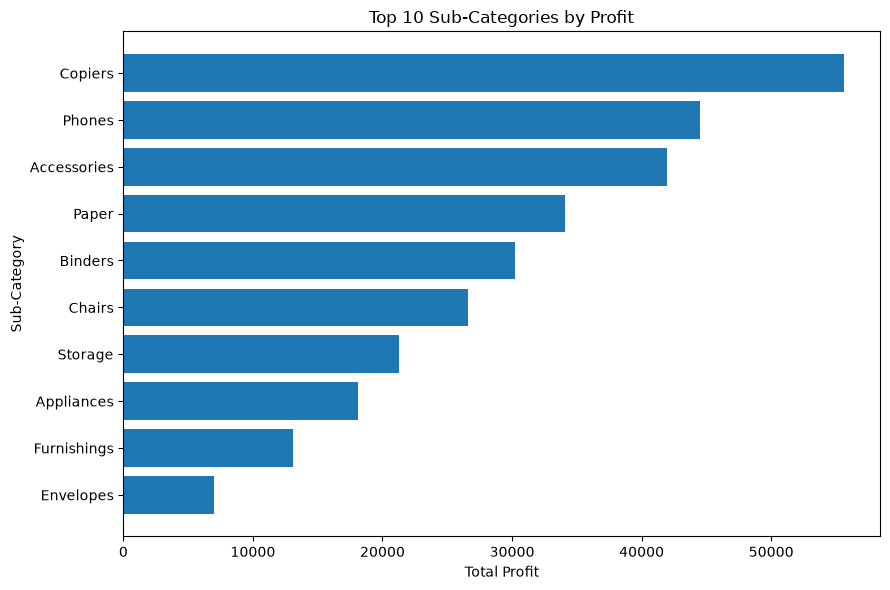

In [81]:
plt.figure(figsize=(9,6))

plt.barh(top10_profit.index,
         top10_profit.values)

plt.title("Top 10 Sub-Categories by Profit")
plt.xlabel("Total Profit")
plt.ylabel("Sub-Category")

plt.gca().invert_yaxis()

plt.tight_layout()

plt.show()

Observation-
Copiers generated the highest profit, followed by Phones and Accessories. These sub-categories contribute significantly to the company's profitability.
Business Insight-
The company should continue investing in highly profitable sub-categories while reviewing low-profit or loss-making sub-categories to improve pricing, discounts, or operational efficiency.

In [ ]:
# correlation Heatmap

In [83]:
correlation = df.corr(numeric_only=True)

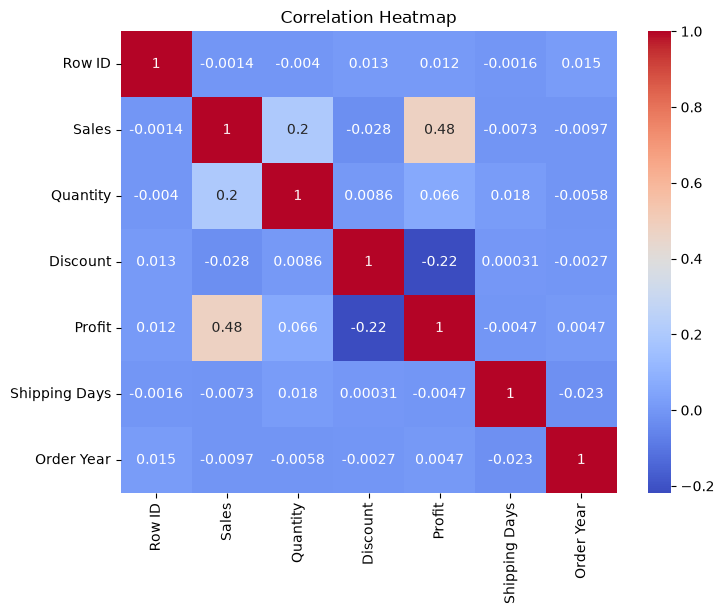

In [84]:
plt.figure(figsize=(8,6))

sns.heatmap(correlation,
            annot=True,
            cmap='coolwarm')

plt.title("Correlation Heatmap")

plt.show()

Observation (Write this below the heatmap)-
The correlation analysis shows a moderate positive relationship between Sales and Profit (0.48), indicating that higher sales generally lead to higher profits. Discount has a negative correlation with Profit (-0.22), suggesting that higher discounts reduce profitability. Quantity has only a weak relationship with Sales and Profit, while Shipping Days and Order Year show almost no correlation with the other numerical variables.

Business Insight-
The company should carefully manage discount strategies, as excessive discounts negatively affect profit. Increasing sales can improve profitability, but maintaining healthy profit margins is equally important.

# Key Business Findings

Key Business Findings
The dataset contains 9,994 records and 21 columns, with only 11 missing values, which were handled during data cleaning.
Technology generated the highest sales and profit among all product categories.
The West region achieved the highest sales and profit, while the Central region generated the lowest profit.
The Consumer segment contributed the highest sales compared to Corporate and Home Office.
Sales increased from 2015 to 2018, with 2018 recording the highest annual sales.
November and December were the highest-performing months in terms of sales.
Some sub-categories generated high sales but comparatively lower profits, showing that high sales do not always result in high profitability.
Correlation analysis showed that Sales and Profit have a moderate positive relationship, while Discount has a negative relationship with Profit.

# Conclusion

This project analyzed the Superstore sales dataset to understand business performance across different categories, regions, customer segments, and time periods. The data was cleaned, feature engineering was performed, and exploratory data analysis along with visualizations helped identify key business trends. Technology products, the West region, and the Consumer segment were the best-performing areas. Sales showed steady growth over the years, with peak sales occurring in November and December. The analysis also revealed that higher discounts negatively impacted profitability. These insights can support better business decisions related to pricing, inventory management, and sales strategy